In [1]:
using DrWatson
    # Cette ligne active le projet à partir du dossier actuel
    @quickactivate "MonProjetSIR" 
    using Random, DataFrames, CSV, Plots
    include(srcdir("SIRPetri.jl"))
    using .SIRPetri

In [8]:
# Параметры
β = 0.3
γ = 0.1
tmax = 100.0

# Создаём сеть
net, u0, states = build_sir_network(β, γ)

# Детерминированная симуляция
df_det = simulate_deterministic(net, u0, (0.0, tmax), saveat = 0.5, rates = [β, γ])
CSV.write(datadir("sir_det.csv"), df_det)

# Стохастическая симуляция
Random.seed!(123)
df_stoch = simulate_stochastic(net, u0, (0.0, tmax), rates = [β, γ])
CSV.write(datadir("sir_stoch.csv"), df_stoch)

"/home/serazanacua/work/study/2025-2026/simulation-modeling/study_2025-2026_simulation-modeling/labs/lab06/project/data/sir_stoch.csv"

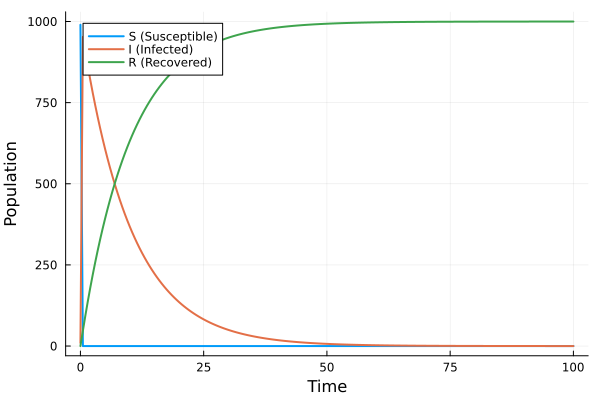

In [9]:
p_det = plot_sir(df_det)
display(p_det) 

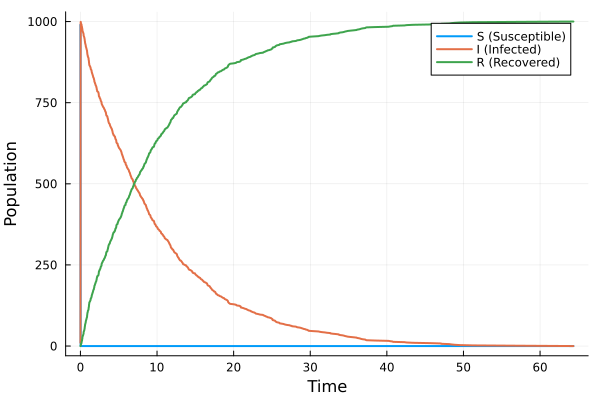

In [11]:
p_stoch = plot_sir(df_stoch)
display(p_stoch)